# **Introducción**

Este análisis tiene como objetivo evaluar el rendimiento de las cuatro tiendas del Sr. João utilizando datos de ventas. Se analizarán factores como los ingresos totales, las categorías de productos más vendidas, la satisfacción de los clientes, los productos más y menos vendidos y el costo promedio de envío.

In [2]:
from google.colab import files
uploaded = files.upload()


Saving tienda_1 .csv to tienda_1 .csv
Saving tienda_2.csv to tienda_2.csv
Saving tienda_3.csv to tienda_3.csv
Saving tienda_4.csv to tienda_4.csv


In [3]:
import pandas as pd


In [6]:
uploaded.keys()


dict_keys(['tienda_1 .csv', 'tienda_2.csv', 'tienda_3.csv', 'tienda_4.csv'])

In [7]:
tienda1 = pd.read_csv("tienda_1 .csv")
tienda2 = pd.read_csv("tienda_2.csv")
tienda3 = pd.read_csv("tienda_3.csv")
tienda4 = pd.read_csv("tienda_4.csv")


In [ ]:
tienda1.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [8]:
tienda1["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"


In [9]:
datos = pd.concat([tienda1, tienda2, tienda3, tienda4])


**INGRESOS TOTALES POR TIENDA**

In [14]:
ingresos_por_tienda = datos.groupby("Tienda")["Precio"].sum().sort_values(ascending=False)
ingresos_por_tienda

,Precio
Tienda,
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


**CATEGORÍAS MÁS VENDIDAS POR TIENDA**


In [17]:
categorias_por_tienda = datos.groupby(["Tienda","Categoría del Producto"])["Producto"].count()

categorias_por_tienda

Tienda    Categoría del Producto 
Tienda 1  Artículos para el hogar    171
          Deportes y diversión       284
          Electrodomésticos          312
          Electrónicos               448
          Instrumentos musicales     182
          Juguetes                   324
          Libros                     173
          Muebles                    465
Tienda 2  Artículos para el hogar    181
          Deportes y diversión       275
          Electrodomésticos          305
          Electrónicos               422
          Instrumentos musicales     224
          Juguetes                   313
          Libros                     197
          Muebles                    442
Tienda 3  Artículos para el hogar    177
          Deportes y diversión       277
          Electrodomésticos          278
          Electrónicos               451
          Instrumentos musicales     177
          Juguetes                   315
          Libros                     185
          Muebles                    499
Tienda 4  Artículos para el hogar    201
          Deportes y diversión       277
          Electrodomésticos          254
          Electrónicos               451
          Instrumentos musicales     170
          Juguetes                   338
          Libros                     187
          Muebles                    480
Name: Producto, dtype: int64

In [21]:
categorias_por_tienda.sort_values(ascending=False)

Tienda    Categoría del Producto 
Tienda 3  Muebles                    499
Tienda 4  Muebles                    480
Tienda 1  Muebles                    465
Tienda 4  Electrónicos               451
Tienda 3  Electrónicos               451
Tienda 1  Electrónicos               448
Tienda 2  Muebles                    442
          Electrónicos               422
Tienda 4  Juguetes                   338
Tienda 1  Juguetes                   324
Tienda 3  Juguetes                   315
Tienda 2  Juguetes                   313
Tienda 1  Electrodomésticos          312
Tienda 2  Electrodomésticos          305
Tienda 1  Deportes y diversión       284
Tienda 3  Electrodomésticos          278
Tienda 4  Deportes y diversión       277
Tienda 3  Deportes y diversión       277
Tienda 2  Deportes y diversión       275
Tienda 4  Electrodomésticos          254
Tienda 2  Instrumentos musicales     224
Tienda 4  Artículos para el hogar    201
Tienda 2  Libros                     197
Tienda 4  Libros                     187
Tienda 3  Libros                     185
Tienda 1  Instrumentos musicales     182
Tienda 2  Artículos para el hogar    181
Tienda 3  Artículos para el hogar    177
          Instrumentos musicales     177
Tienda 1  Libros                     173
          Artículos para el hogar    171
Tienda 4  Instrumentos musicales     170
Name: Producto, dtype: int64

**CALIFICACIÓN PROMEDIO DE CLIENTES**



In [23]:
calificaciones = datos.groupby("Tienda")["Calificación"].mean().sort_values(ascending=False)
calificaciones

,Calificación
Tienda,
Tienda 3,4.048326
Tienda 2,4.037304
Tienda 4,3.995759
Tienda 1,3.976685


**PRODUCTOS MÁS Y MENOS VENDIDOS**

In [24]:
productos_vendidos = datos.groupby("Producto")["Producto"].count().sort_values(ascending=False)

mas_vendidos = productos_vendidos.head(10)
menos_vendidos = productos_vendidos.tail(10)

mas_vendidos

,Producto
Producto,
Mesa de noche,210
Microondas,206
Carrito de control remoto,206
Batería,203
Cama king,201
Modelado predictivo,200
Secadora de ropa,200
Set de ollas,200
Cama box,199


**COSTO PROMEDIO DE ENVÍO**


In [13]:
envio_promedio = datos.groupby("Tienda")["Costo de envío"].mean().sort_values()
envio_promedio

,Costo de envío
Tienda,
Tienda 4,23459.457167
Tienda 3,24805.680373
Tienda 2,25216.235693
Tienda 1,26018.609580


**GRÁFICAS**


In [16]:
import matplotlib.pyplot as plt

**Gráfico 1 — Ingresos por tienda**

In [ ]:
ingresos = datos.groupby("Tienda")["Precio"].sum().sort_values(ascending=False)

ingresos

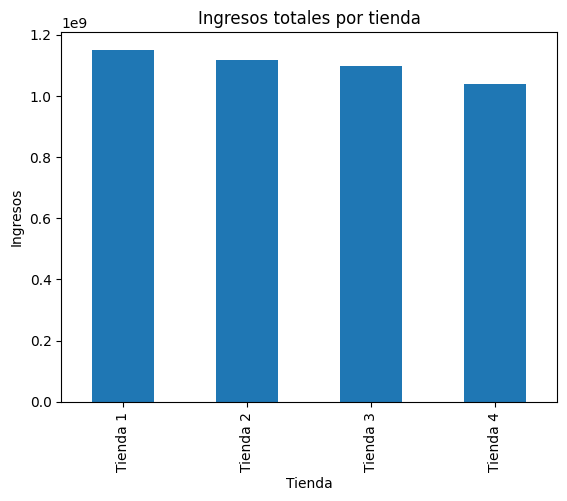

In [20]:
ingresos.plot(kind="bar")

plt.title("Ingresos totales por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingresos")
plt.show()

**Gráfico 2 — Calificación promedio**

In [23]:
calificaciones = datos.groupby("Tienda")["Calificación"].mean().sort_values(ascending=False)

calificaciones

,Calificación
Tienda,
Tienda 3,4.048326
Tienda 2,4.037304
Tienda 4,3.995759
Tienda 1,3.976685


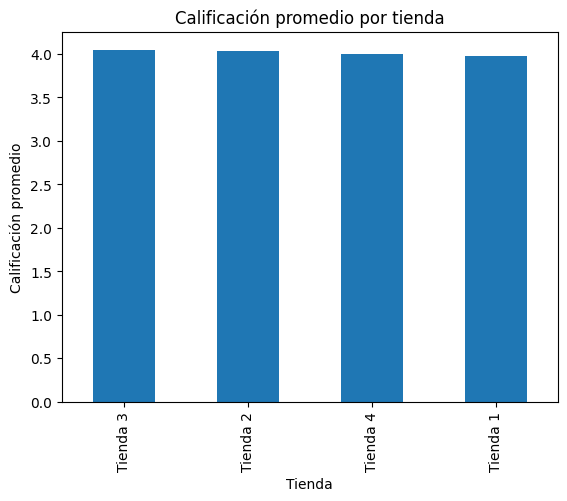

In [24]:
calificaciones.plot(kind="bar")

plt.title("Calificación promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Calificación promedio")
plt.show()

**Gráfico 3 — Categorías más vendidas**

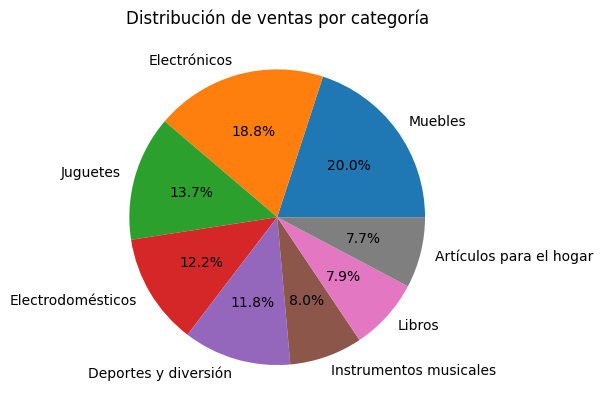

In [26]:
categorias_totales = datos["Categoría del Producto"].value_counts()

categorias_totales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Distribución de ventas por categoría")
plt.ylabel("")
plt.show()

**Conclusión**

Después de analizar los datos de las cuatro tiendas, se evaluaron varios factores importantes: ingresos totales, categorías más vendidas, satisfacción de los clientes, productos más vendidos y costo promedio de envío.

Los resultados muestran diferencias claras en el desempeño de cada tienda. Algunas presentan mayores ingresos y mejores calificaciones de clientes, mientras que otras muestran un desempeño más bajo en comparación.

Teniendo en cuenta estos factores, Considerando todos los indicadores analizados, se observa que la Tienda 4 presenta el menor ingreso total entre las cuatro tiendas, lo que indica un rendimiento comercial inferior. Aunque cuenta con el costo de envío promedio más bajo y una calificación de clientes aceptable, su volumen de ventas y generación de ingresos es menor en comparación con las demás tiendas.

Por esta razón, se recomienda que el Sr. João considere vender la Tienda 4, ya que su desempeño general es el más bajo en términos de ingresos. Esta decisión permitiría concentrar recursos e inversiones en las tiendas con mayor potencial de ventas y mejor desempeño financiero.

